Dispositivo utilizado: cuda
=== CNN AVANÇADA PARA CLASSIFICAÇÃO DE PNEUMONIA COM DENSENET-121 ===
Carregando datasets...
Dataset carregado: 46025 amostras de ./difusion_dataset_organizado/train
  normal: 11536 amostras
  covid19: 11497 amostras
  pneumonia_viral: 11474 amostras
  pneumonia_bacterial: 11518 amostras
Dataset carregado: 9432 amostras de ./difusion_dataset_organizado/val
  normal: 2364 amostras
  covid19: 2356 amostras
  pneumonia_viral: 2351 amostras
  pneumonia_bacterial: 2361 amostras
Dataset carregado: 9437 amostras de ./difusion_dataset_organizado/test
  normal: 2366 amostras
  covid19: 2357 amostras
  pneumonia_viral: 2353 amostras
  pneumonia_bacterial: 2361 amostras
Pesos das classes: tensor([1.0008, 0.9974, 0.9990, 1.0028], device='cuda:0')
Inicializando modelo...
Iniciando treinamento por 50 épocas...
------------------------------------------------------------
Época 1/50
Batch 0/1439, Loss: 17.0658
Batch 50/1439, Loss: 10.5064
Batch 100/1439, Loss: 5.7626
Batch 

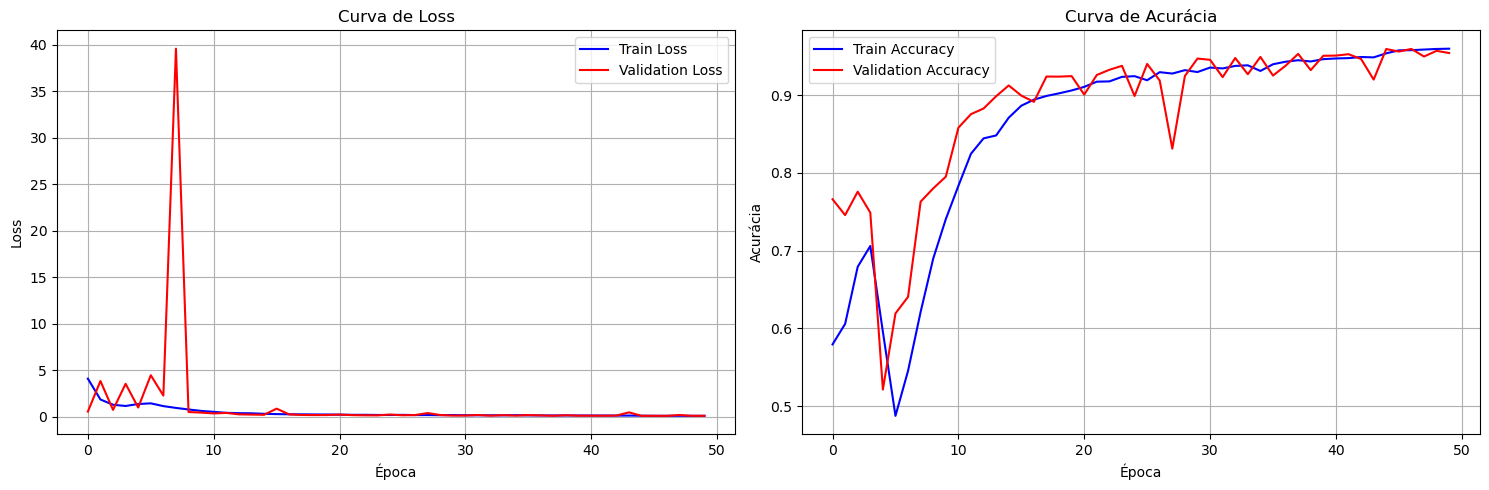

Carregando melhor modelo para avaliação final...

=== AVALIAÇÃO NO CONJUNTO DE TESTE ===
=== RELATÓRIO DE CLASSIFICAÇÃO ===
                     precision    recall  f1-score   support

            covid19     0.9664    0.9881    0.9771      2357
             normal     0.9793    0.9603    0.9697      2366
pneumonia_bacterial     0.9617    0.9348    0.9480      2361
    pneumonia_viral     0.9324    0.9558    0.9440      2353

           accuracy                         0.9597      9437
          macro avg     0.9599    0.9597    0.9597      9437
       weighted avg     0.9600    0.9597    0.9597      9437



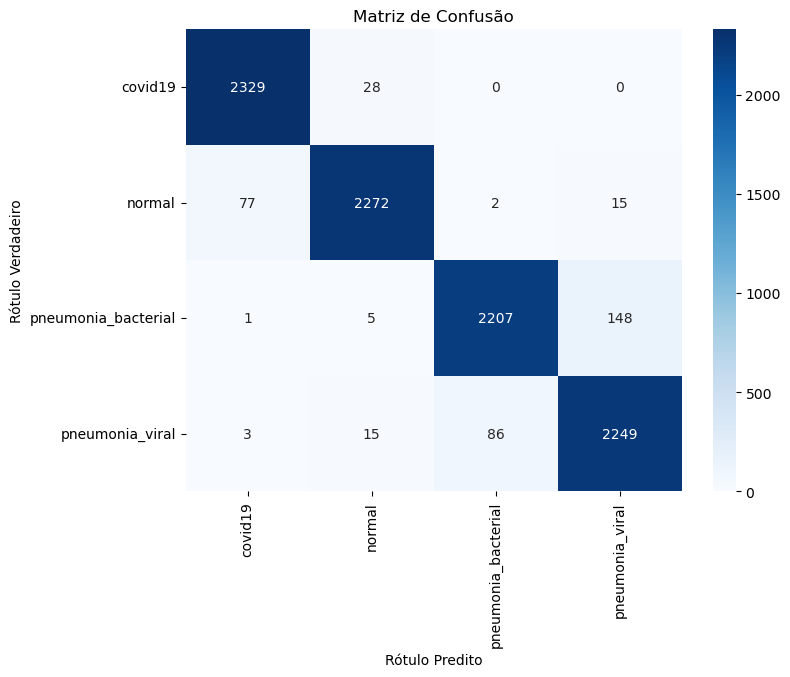

AUC covid19: 0.9993
AUC normal: 0.9986
AUC pneumonia_bacterial: 0.9971
AUC pneumonia_viral: 0.9964
AUC Médio: 0.9978

Treinamento e avaliação concluídos com sucesso!
Melhor acurácia de validação: 0.9595


In [ ]:
import os
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision.transforms as transforms
from torch.utils.data import Dataset, DataLoader
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score
import seaborn as sns
from collections import Counter
from torchvision import models
import torch.nn.functional as F

# Configuração de dispositivo
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Dispositivo utilizado: {device}")

class ChestXRayDataset(Dataset):
    """Dataset personalizado para classificação de pneumonia"""
    def __init__(self, root_dir, transform=None):
        self.samples = []
        self.transform = transform
        self.root_dir = root_dir
        self.class_names = ['covid19', 'normal', 'pneumonia_bacterial', 'pneumonia_viral']
        label_mapping = {name: idx for idx, name in enumerate(self.class_names)}
        for label_name in os.listdir(root_dir):
            label_dir = os.path.join(root_dir, label_name)
            if not os.path.isdir(label_dir):
                continue
            label = label_mapping.get(label_name.lower())
            if label is None:
                continue
            for img_name in os.listdir(label_dir):
                img_path = os.path.join(label_dir, img_name)
                self.samples.append((img_path, label))
        print(f"Dataset carregado: {len(self.samples)} amostras de {root_dir}")
        self._print_class_distribution()

    def _print_class_distribution(self):
        labels = [sample[1] for sample in self.samples]
        class_counts = Counter(labels)
        for class_idx, count in class_counts.items():
            print(f"  {self.class_names[class_idx]}: {count} amostras")

    def get_class_weights(self):
        labels = [sample[1] for sample in self.samples]
        class_counts = Counter(labels)
        total_samples = len(self.samples)
        weights = []
        for i in range(len(self.class_names)):
            if i in class_counts:
                weight = total_samples / (len(self.class_names) * class_counts[i])
                weights.append(weight)
            else:
                weights.append(0.0)
        return torch.FloatTensor(weights)

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        img_path, label = self.samples[idx]
        try:
            image = Image.open(img_path).convert("RGB")
            if self.transform:
                image = self.transform(image)
            return image, label
        except Exception as e:
            print(f"Erro ao carregar imagem {img_path}: {e}")
            dummy_image = torch.zeros(3, 224, 224)
            return dummy_image, label

def get_transforms(phase='train'):
    if phase == 'train':
        return transforms.Compose([
            transforms.Resize((256, 256)),
            transforms.RandomResizedCrop(224, scale=(0.8, 1.0)),
            transforms.RandomHorizontalFlip(p=0.5),
            transforms.RandomRotation(degrees=10),
            transforms.ColorJitter(brightness=0.2, contrast=0.2),
            transforms.ToTensor(),
            transforms.Normalize(mean=[0.485, 0.456, 0.406],
                                 std=[0.229, 0.224, 0.225])
        ])
    else:
        return transforms.Compose([
            transforms.Resize((224, 224)),
            transforms.ToTensor(),
            transforms.Normalize(mean=[0.485, 0.456, 0.406],
                                 std=[0.229, 0.224, 0.225])
        ])

class AdvancedDenseNet(nn.Module):
    """CNN avançada com Transfer Learning usando DenseNet-121"""
    def __init__(self, num_classes=4, pretrained=True, dropout_rate=0.5):
        super(AdvancedDenseNet, self).__init__()
        self.backbone = models.densenet121(weights='IMAGENET1K_V1' if pretrained else None)
        num_features = self.backbone.classifier.in_features
        self.backbone.classifier = nn.Identity()
        self.classifier = nn.Sequential(
            nn.Dropout(dropout_rate),
            nn.Linear(num_features, 512),
            nn.ReLU(),
            nn.BatchNorm1d(512),
            nn.Dropout(dropout_rate),
            nn.Linear(512, 256),
            nn.ReLU(),
            nn.BatchNorm1d(256),
            nn.Dropout(dropout_rate),
            nn.Linear(256, num_classes)
        )
        self._initialize_weights()

    def _initialize_weights(self):
        for m in self.classifier.modules():
            if isinstance(m, nn.Linear):
                nn.init.kaiming_normal_(m.weight, mode='fan_out', nonlinearity='relu')
                nn.init.constant_(m.bias, 0)
            elif isinstance(m, nn.BatchNorm1d):
                nn.init.constant_(m.weight, 1)
                nn.init.constant_(m.bias, 0)

    def forward(self, x):
        features = self.backbone.features(x)
        out = F.relu(features, inplace=True)
        out = F.adaptive_avg_pool2d(out, (1, 1)).view(x.size(0), -1)
        return self.classifier(out)

class ModelTrainer:
    def __init__(self, model, train_loader, val_loader, criterion, optimizer,
                 scheduler=None, device='cpu'):
        self.model = model
        self.train_loader = train_loader
        self.val_loader = val_loader
        self.criterion = criterion
        self.optimizer = optimizer
        self.scheduler = scheduler
        self.device = device
        self.train_losses = []
        self.train_accuracies = []
        self.val_losses = []
        self.val_accuracies = []

    def train_epoch(self):
        self.model.train()
        running_loss = 0.0
        correct_predictions = 0
        total_samples = 0
        for batch_idx, (images, labels) in enumerate(self.train_loader):
            images, labels = images.to(self.device), labels.to(self.device)
            outputs = self.model(images)
            loss = self.criterion(outputs, labels)
            self.optimizer.zero_grad()
            loss.backward()
            self.optimizer.step()
            running_loss += loss.item()
            _, predicted = torch.max(outputs, 1)
            correct_predictions += (predicted == labels).sum().item()
            total_samples += labels.size(0)
            if batch_idx % 50 == 0:
                print(f'Batch {batch_idx}/{len(self.train_loader)}, Loss: {loss.item():.4f}')
        epoch_loss = running_loss / len(self.train_loader)
        epoch_acc = correct_predictions / total_samples
        return epoch_loss, epoch_acc

    def validate_epoch(self):
        self.model.eval()
        running_loss = 0.0
        correct_predictions = 0
        total_samples = 0
        with torch.no_grad():
            for images, labels in self.val_loader:
                images, labels = images.to(self.device), labels.to(self.device)
                outputs = self.model(images)
                loss = self.criterion(outputs, labels)
                running_loss += loss.item()
                _, predicted = torch.max(outputs, 1)
                correct_predictions += (predicted == labels).sum().item()
                total_samples += labels.size(0)
        epoch_loss = running_loss / len(self.val_loader)
        epoch_acc = correct_predictions / total_samples
        return epoch_loss, epoch_acc

    def train(self, num_epochs, early_stopping_patience=10):
        best_val_acc = 0.0
        patience_counter = 0
        print(f"Iniciando treinamento por {num_epochs} épocas...")
        print("-" * 60)
        for epoch in range(num_epochs):
            print(f'Época {epoch+1}/{num_epochs}')
            train_loss, train_acc = self.train_epoch()
            val_loss, val_acc = self.validate_epoch()
            if self.scheduler:
                self.scheduler.step(val_loss)
            self.train_losses.append(train_loss)
            self.train_accuracies.append(train_acc)
            self.val_losses.append(val_loss)
            self.val_accuracies.append(val_acc)
            print(f'Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.4f}')
            print(f'Val Loss: {val_loss:.4f}, Val Acc: {val_acc:.4f}')
            if val_acc > best_val_acc:
                best_val_acc = val_acc
                patience_counter = 0
                torch.save({
                    'epoch': epoch,
                    'model_state_dict': self.model.state_dict(),
                    'optimizer_state_dict': self.optimizer.state_dict(),
                    'val_acc': val_acc,
                    'val_loss': val_loss
                }, 'best_model.pth')
                print(f'Novo melhor modelo salvo! Val Acc: {val_acc:.4f}')
            else:
                patience_counter += 1
            if patience_counter >= early_stopping_patience:
                print(f'Early stopping após {early_stopping_patience} épocas sem melhoria')
                break
            print("-" * 60)
        print(f'Treinamento concluído! Melhor Val Acc: {best_val_acc:.4f}')
        return best_val_acc

    def plot_training_history(self):
        fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))
        ax1.plot(self.train_losses, label='Train Loss', color='blue')
        ax1.plot(self.val_losses, label='Validation Loss', color='red')
        ax1.set_title('Curva de Loss')
        ax1.set_xlabel('Época')
        ax1.set_ylabel('Loss')
        ax1.legend()
        ax1.grid(True)
        ax2.plot(self.train_accuracies, label='Train Accuracy', color='blue')
        ax2.plot(self.val_accuracies, label='Validation Accuracy', color='red')
        ax2.set_title('Curva de Acurácia')
        ax2.set_xlabel('Época')
        ax2.set_ylabel('Acurácia')
        ax2.legend()
        ax2.grid(True)
        plt.tight_layout()
        plt.savefig('training_history.png', dpi=300, bbox_inches='tight')
        plt.show()

def evaluate_model(model, test_loader, device, class_names):
    model.eval()
    all_predictions = []
    all_labels = []
    all_probabilities = []
    with torch.no_grad():
        for images, labels in test_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            probabilities = F.softmax(outputs, dim=1)
            _, predicted = torch.max(outputs, 1)
            all_predictions.extend(predicted.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
            all_probabilities.extend(probabilities.cpu().numpy())
    print("=== RELATÓRIO DE CLASSIFICAÇÃO ===")
    print(classification_report(all_labels, all_predictions,
                               target_names=class_names, digits=4))
    cm = confusion_matrix(all_labels, all_predictions)
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=class_names, yticklabels=class_names)
    plt.title('Matriz de Confusão')
    plt.ylabel('Rótulo Verdadeiro')
    plt.xlabel('Rótulo Predito')
    plt.savefig('confusion_matrix.png', dpi=300, bbox_inches='tight')
    plt.show()
    all_probabilities = np.array(all_probabilities)
    try:
        auc_scores = {}
        for i, class_name in enumerate(class_names):
            binary_labels = (np.array(all_labels) == i).astype(int)
            auc = roc_auc_score(binary_labels, all_probabilities[:, i])
            auc_scores[class_name] = auc
            print(f"AUC {class_name}: {auc:.4f}")
        mean_auc = np.mean(list(auc_scores.values()))
        print(f"AUC Médio: {mean_auc:.4f}")
    except Exception as e:
        print(f"Erro ao calcular AUC: {e}")
    return all_predictions, all_labels, all_probabilities

def main():
    DATA_DIR = './dataset_organizado'
    BATCH_SIZE = 32
    NUM_EPOCHS = 50
    LEARNING_RATE = 0.001
    WEIGHT_DECAY = 1e-4
    print("=== CNN AVANÇADA PARA CLASSIFICAÇÃO DE PNEUMONIA COM DENSENET-121 ===")
    print("=" * 60)
    if not os.path.exists(DATA_DIR):
        print(f"ERRO: Diretório {DATA_DIR} não encontrado!")
        print("Por favor, ajuste o caminho DATA_DIR no código.")
        return
    try:
        print("Carregando datasets...")
        train_dataset = ChestXRayDataset(
            os.path.join(DATA_DIR, 'train'),
            transform=get_transforms('train')
        )
        val_dataset = ChestXRayDataset(
            os.path.join(DATA_DIR, 'val'),
            transform=get_transforms('val')
        )
        test_dataset = ChestXRayDataset(
            os.path.join(DATA_DIR, 'test'),
            transform=get_transforms('test')
        )
        class_weights = train_dataset.get_class_weights().to(device)
        print(f"Pesos das classes: {class_weights}")
        train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE,
                                  shuffle=True, num_workers=4, pin_memory=True)
        val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE,
                                shuffle=False, num_workers=4, pin_memory=True)
        test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE,
                                 shuffle=False, num_workers=4, pin_memory=True)
        print("Inicializando modelo...")
        model = AdvancedDenseNet(num_classes=4, pretrained=True, dropout_rate=0.5)
        model = model.to(device)
        criterion = nn.CrossEntropyLoss(weight=class_weights)
        optimizer = optim.AdamW(model.parameters(), lr=LEARNING_RATE,
                                weight_decay=WEIGHT_DECAY)
        scheduler = optim.lr_scheduler.ReduceLROnPlateau(
            optimizer, mode='min', factor=0.5, patience=5 #verbose=True
        )
        trainer = ModelTrainer(model, train_loader, val_loader, criterion,
                               optimizer, scheduler, device)
        best_val_acc = trainer.train(NUM_EPOCHS, early_stopping_patience=10)
        trainer.plot_training_history()
        if os.path.exists('GUN_best_model.pth'):
            print("Carregando melhor modelo para avaliação final...")
            checkpoint = torch.load('GUN_best_model.pth', map_location=device)
            model.load_state_dict(checkpoint['model_state_dict'])
        print("\n=== AVALIAÇÃO NO CONJUNTO DE TESTE ===")
        class_names = ['covid19', 'normal', 'pneumonia_bacterial', 'pneumonia_viral']
        predictions, labels, probabilities = evaluate_model(
            model, test_loader, device, class_names
        )
        print("\nTreinamento e avaliação concluídos com sucesso!")
        print(f"Melhor acurácia de validação: {best_val_acc:.4f}")
    except Exception as e:
        print(f"Erro durante a execução: {e}")
        print("Verifique se o dataset está organizado corretamente:")
        print("dataset_organizado/")
        print("├── train/")
        print("│   ├── covid19/")
        print("│   ├── normal/")
        print("│   ├── pneumonia_bacterial/")
        print("│   └── pneumonia_viral/")
        print("├── val/")
        print("│   ├── covid19/")
        print("│   ├── normal/")
        print("│   ├── pneumonia_bacterial/")
        print("│   └── pneumonia_viral/")
        print("└── test/")
        print("    ├── covid19/")
        print("    ├── normal/")
        print("    ├── pneumonia_bacterial/")
        print("    └── pneumonia_viral/")

if __name__ == "__main__":
    main()
